In [47]:
# Import required packages
import torch
import numpy as np
import normflows as nf
import pandas as pd

from matplotlib import pyplot as plt

from tqdm import tqdm

In [65]:
# Set up model

# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(2)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))
    
# Construct flow model
model = nf.NormalizingFlow(base, flows)

In [66]:
# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

In [67]:
# Define target distribution

def sample_generator(size):
    x = np.random.normal(0, 1, size)
    y = np.random.normal(0, 0.3, size)
    u = np.random.rand(size) < 0.5
    x1 = np.where(u, 2 * x, x)
    y1 = np.where(u, x1, -x1) + y
    return np.column_stack((x1, y1))

#target = nf.distributions.RingMixture()

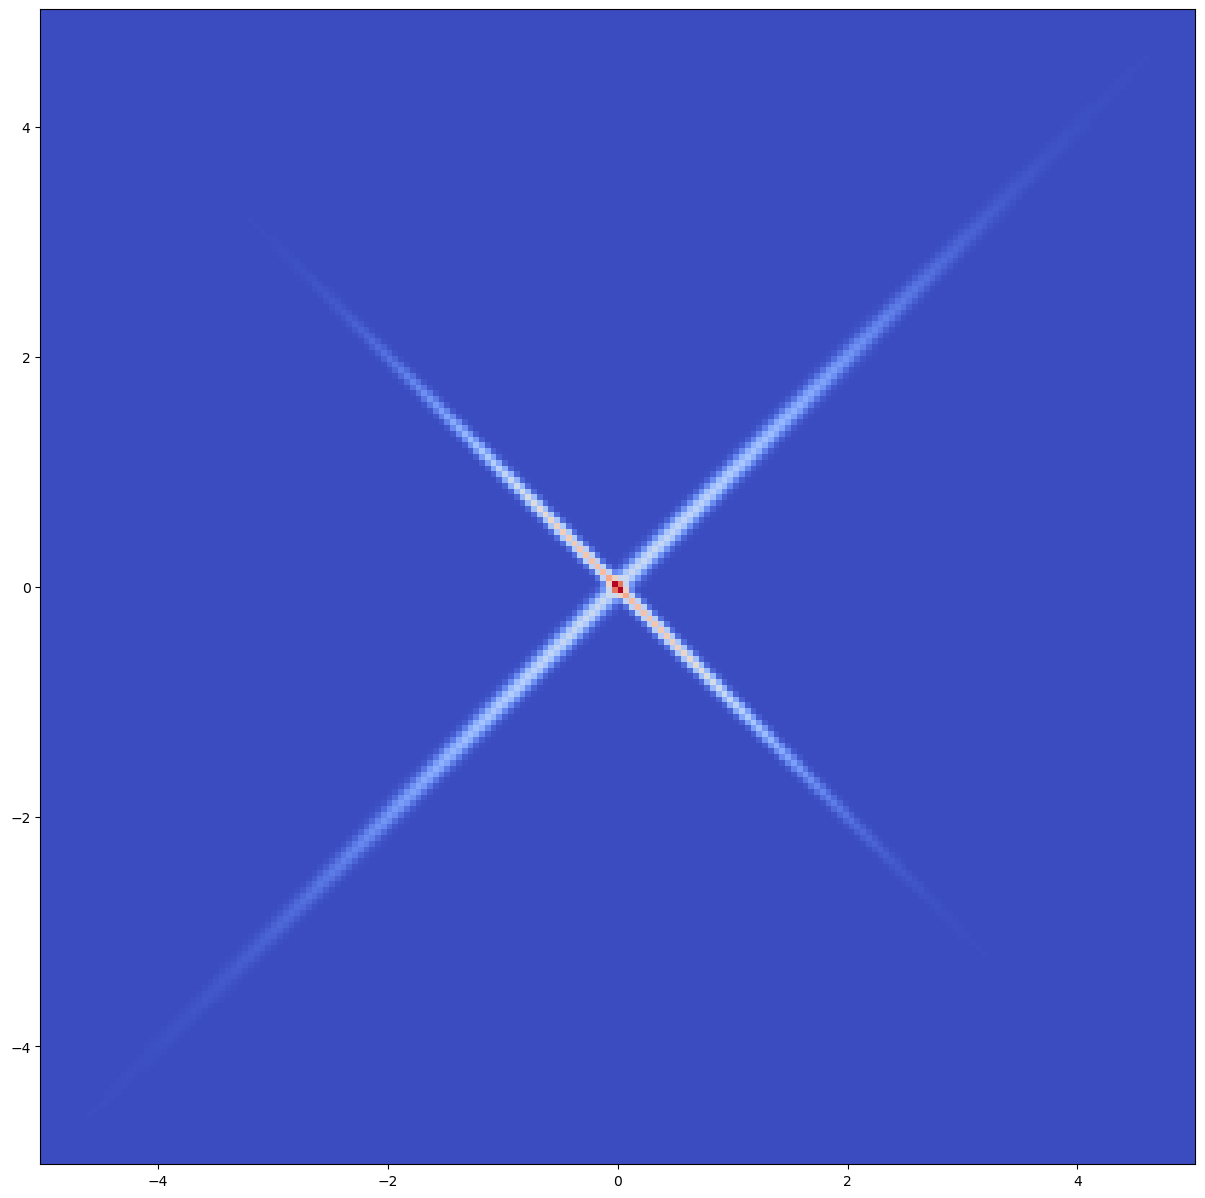

In [68]:
# Plot target distribution
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-5, 5, grid_size), torch.linspace(-5, 5, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

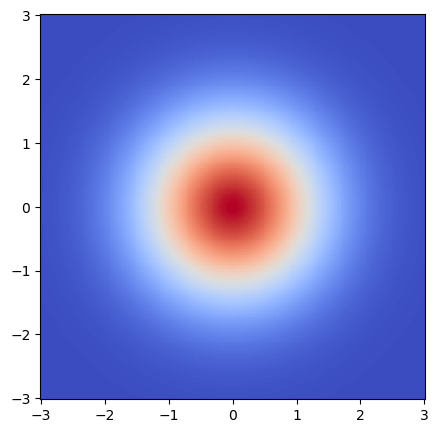

In [29]:
# Plot initial flow distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(5, 5))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()

  0%|          | 1/1500 [00:00<06:07,  4.08it/s]

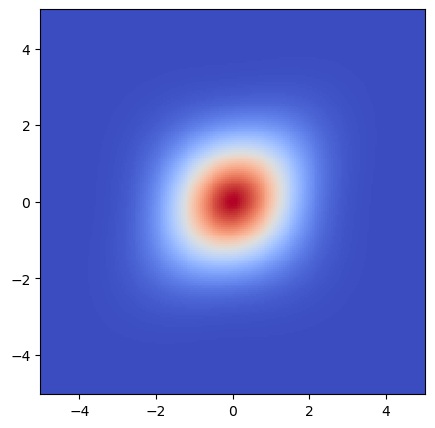

  0%|          | 2/1500 [00:00<06:20,  3.94it/s]

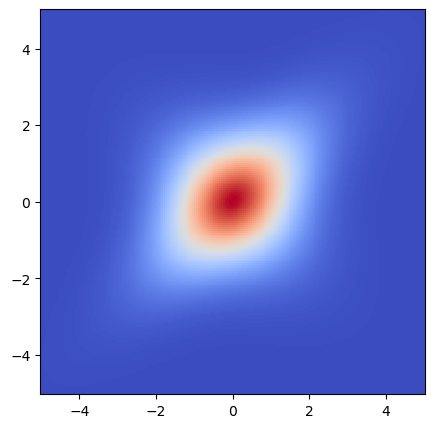

  0%|          | 4/1500 [00:00<05:37,  4.43it/s]

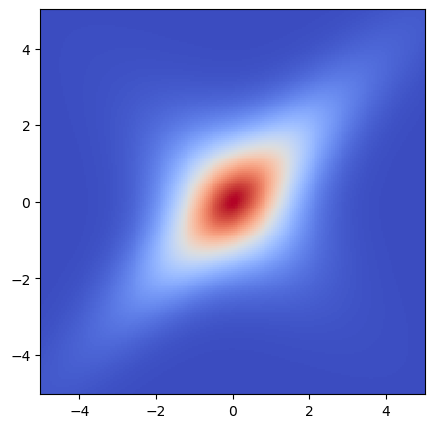

  1%|          | 15/1500 [00:01<01:29, 16.60it/s]

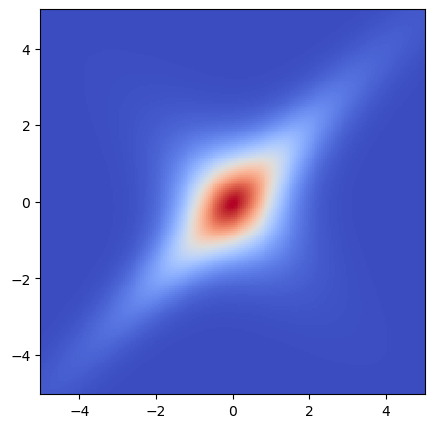

  2%|▏         | 25/1500 [00:01<01:07, 21.99it/s]

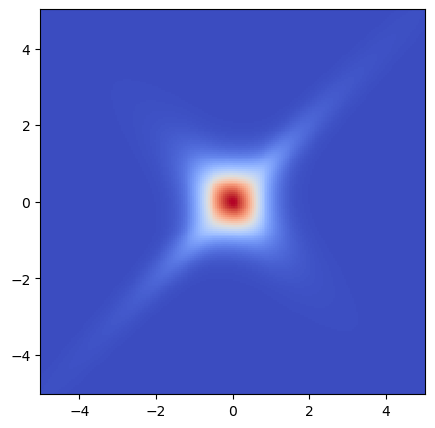

  4%|▍         | 60/1500 [00:02<00:30, 47.32it/s]

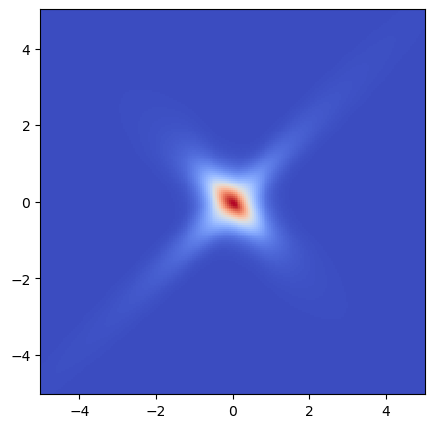

  8%|▊         | 123/1500 [00:03<00:22, 62.28it/s]

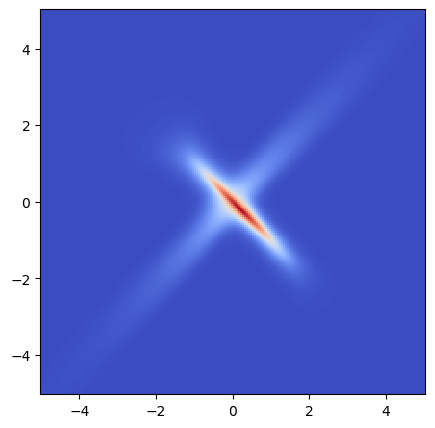

 17%|█▋        | 249/1500 [00:05<00:18, 66.71it/s]

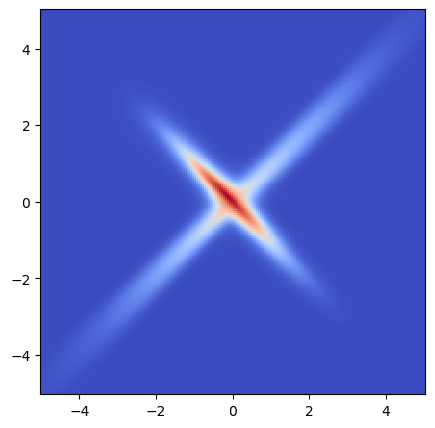

 34%|███▍      | 508/1500 [00:10<00:14, 66.27it/s]

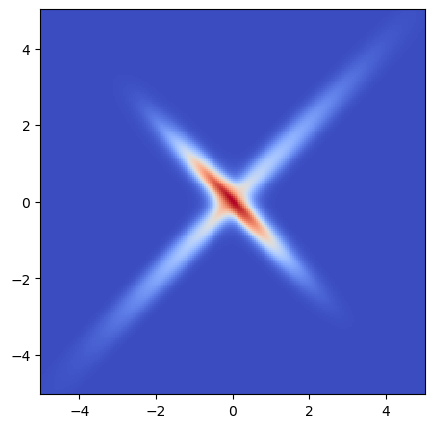

 68%|██████▊   | 1019/1500 [00:18<00:07, 63.14it/s]

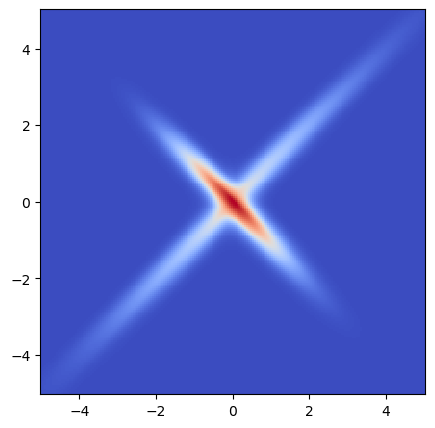

100%|██████████| 1500/1500 [00:25<00:00, 58.47it/s]


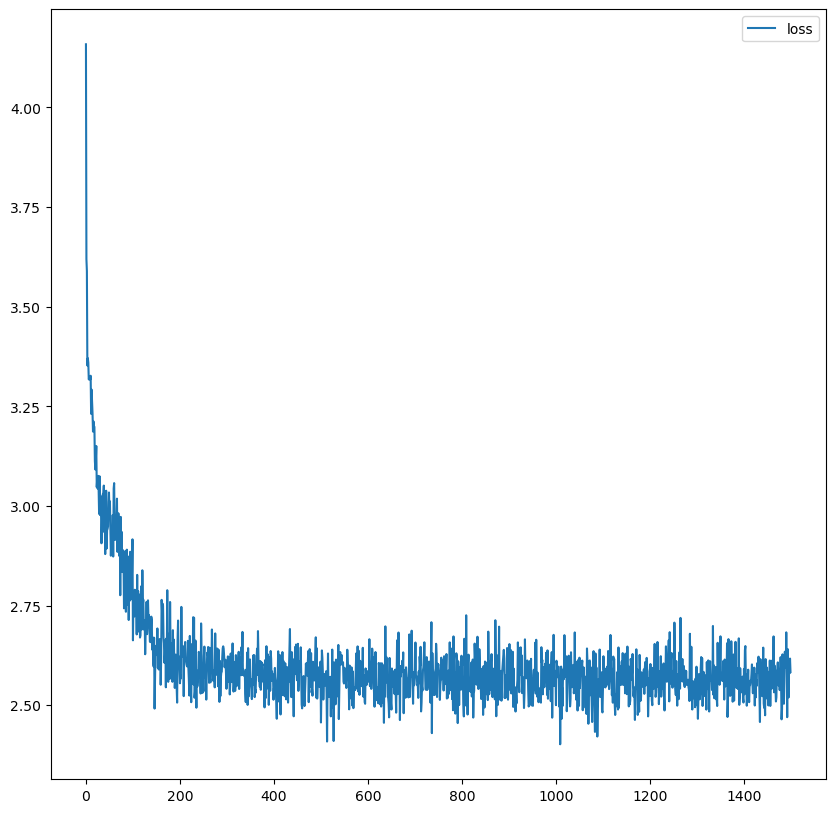

In [69]:
# Train model
max_iter = 1500
num_samples = 512
show_iter = 2


loss_hist = np.array([])
plot_data = []

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()
    
    # Get training samples
    x = torch.from_numpy(sample_generator(num_samples)).float().to(device)
    
    # Compute loss
    loss = model.forward_kld(x)
    
    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()
    
    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
    
    # Plot learned distribution
    if (it + 1) % show_iter == 0:
        show_iter *= 2
        model.eval()
        log_prob = model.log_prob(zz)
        model.train()
        prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
        prob[torch.isnan(prob)] = 0
        plot_df = pd.DataFrame({
        'x': xx.cpu().numpy().ravel(),
        'y': yy.cpu().numpy().ravel(),
        'density': prob.detach().cpu().numpy().ravel(),
        'iteration': it + 1})
        plot_data.append(plot_df)
        plt.figure(figsize=(5, 5))
        plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
        plt.gca().set_aspect('equal', 'box')
        plt.show()

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

final_df = pd.concat(plot_data, ignore_index=True)
final_df.to_csv("nf_training_progress.csv", index=False)

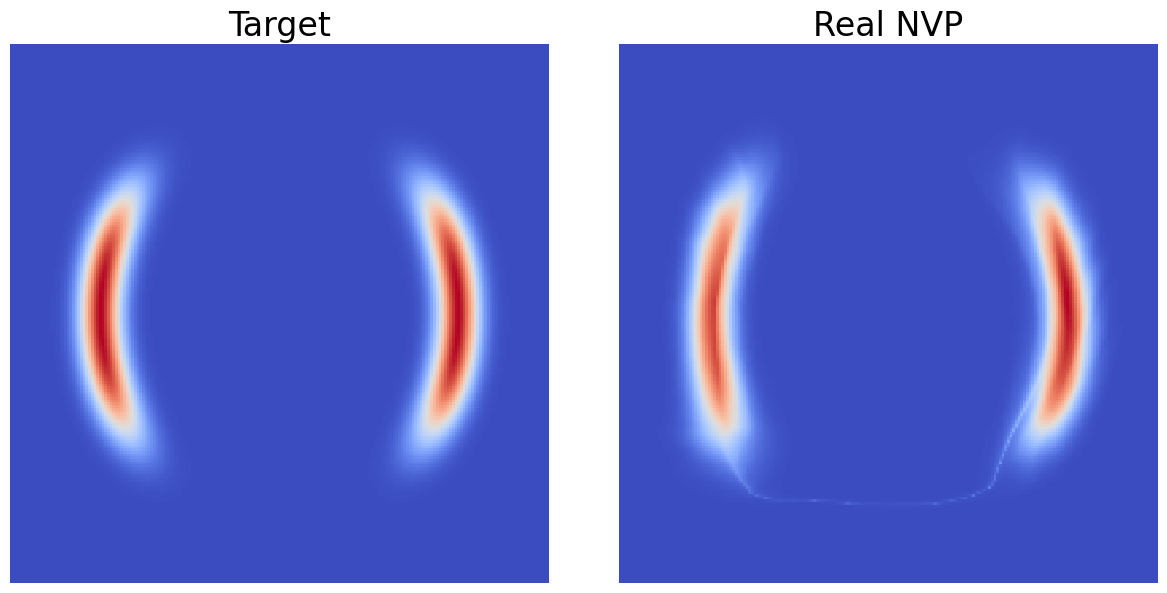

In [8]:
# Plot target distribution
f, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 7))

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

ax[0].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[0].set_aspect('equal', 'box')
ax[0].set_axis_off()
ax[0].set_title('Target', fontsize=24)

# Plot learned distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

ax[1].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[1].set_aspect('equal', 'box')
ax[1].set_axis_off()
ax[1].set_title('Real NVP', fontsize=24)

plt.subplots_adjust(wspace=0.1)

plt.show()